<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import io
import os
import math
import json
import random
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.utils import pad_sequences, timeseries_dataset_from_array
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from keras.utils import to_categorical


import urllib.request
import bs4 as bs

# Book
Tried using The Count of Monte Cristo (Spanish version) but it crashed. Seems book is too long (after cleanup, 2.5 million characters).

After that, we tried The Adventures of Sherlock Holmes (Spanish version), which is 601231 characters after cleanup. Crashed during training.

Since it's a compilation of short stories, we tried extracting the stories that make up around the first half of the book. This also crashed.

We then moved to Cuentos de la Selva. This also crashed so, after some research, we resorted to use numpy's sliding window view. The culprit seems to have been the callback that calculates the validation perplexity. We modify it.

All of this still crashed, so we moved to using TensorFlow's  timeseries_dataset_from_array as a last resort before considering a different (and shorter) book.

In [ ]:
# Fetch from textos.info
raw_html = urllib.request.urlopen(
    "https://www.textos.info/horacio-quiroga/cuentos-de-la-selva/ebook"
).read()

# Parse with lxml
book_html = bs.BeautifulSoup(raw_html, "lxml")

# Get paragraphs as a list
book_paragraphs = book_html.find_all("p")
#pslice_idx = (len(book_paragraphs) // 2) + 145
#book_paragraphs = book_paragraphs[:pslice_idx]

# Get complete text in lower case. Replace soft hypens as well
book_text = " ".join(paragraph.text.lower().replace("\xad", "") for paragraph in book_paragraphs)

# Remove lineskips.
book_text = " ".join(book_text.split())

In [ ]:
# Text looks clean after removing lineskips and soft hyphens.
book_text[:5000]

'había una vez una banda de loros que vivía en el monte. de mañana temprano iban a comer choclos a la chacra, y de tarde comían naranjas. hacían gran barullo con sus gritos, y tenían siempre un loro de centinela en los árboles más altos, para ver si venía alguien. los loros son tan dañinos como la langosta, porque abren los choclos para picotearlos, los cuales, después, se pudren con la lluvia. y como al mismo tiempo los loros son ricos para comer guisados, los peones los cazaban a tiros. un día un hombre bajó de un tiro a un loro centinela, el que cayó herido y peleó un buen rato antes de dejarse agarrar. el peón lo llevó a la casa, para los hijos del patrón, los chicos lo curaron porque no tenía más que un ala rota— el loro se curó bien, y se amansó completamente. se llamaba pedrito. aprendió a dar la pata; le gustaba estar en el hombro de las personas y con el pico les hacía cosquillas en la oreja. vivía suelto, y pasaba casi todo el día en los naranjos y eucaliptos del jardín. le g

In [ ]:
# Remove dedication.
#book_text = book_text[78:] # Leftover from Sherlock Holmes code.

# Text length.
print(f"Book length: {len(book_text)}")

Book length: 97027


### Context window

In [ ]:
# Get average paragraph length.
np.mean([len(p.text) for p in book_paragraphs])

np.float64(155.14171974522293)

In [ ]:
# The criteria used will be the smallest power of two that's bigger than
# twice the average paragraph length.
# In our case it's ~155, so it'll be 512.
max_context_size = 2 ** math.ceil(
    math.log2(2 * np.mean([len(p.text) for p in book_paragraphs]))
)
max_context_size

512

###  Tokenize

In [ ]:
# Our vocabulary will be unique characters.
chars_vocab = set(book_text)
print(f'Vocabulary size: {len(chars_vocab)}\nVocabulary: {chars_vocab}')

Vocabulary size: 61
Vocabulary: {'r', ')', 'k', '"', '/', "'", '¡', '!', '7', '-', 'u', 'c', 'ó', 'i', '8', 'm', '9', 'l', ':', ',', '3', ' ', 'f', '?', '0', '(', 'z', 'é', 'b', 'o', 'x', '»', '2', '¿', 'y', 'n', '4', '1', 'j', ';', 't', '«', 'á', 'g', 'w', 'q', 's', 'a', 'ü', 'ú', 'h', '5', 'ñ', '—', '6', 'd', 'í', 'p', '.', 'v', 'e'}


In [ ]:
# Set character, index dictionaries.
c2i = {character: idx for idx, character in enumerate(chars_vocab)}
i2c = {idx: character for character, idx in c2i.items()}

In [ ]:
# Tokenize text.
tokenized_text = [c2i[character] for character in book_text]

print(tokenized_text[:500])

[50, 47, 28, 56, 47, 21, 10, 35, 47, 21, 59, 60, 26, 21, 10, 35, 47, 21, 28, 47, 35, 55, 47, 21, 55, 60, 21, 17, 29, 0, 29, 46, 21, 45, 10, 60, 21, 59, 13, 59, 56, 47, 21, 60, 35, 21, 60, 17, 21, 15, 29, 35, 40, 60, 58, 21, 55, 60, 21, 15, 47, 52, 47, 35, 47, 21, 40, 60, 15, 57, 0, 47, 35, 29, 21, 13, 28, 47, 35, 21, 47, 21, 11, 29, 15, 60, 0, 21, 11, 50, 29, 11, 17, 29, 46, 21, 47, 21, 17, 47, 21, 11, 50, 47, 11, 0, 47, 19, 21, 34, 21, 55, 60, 21, 40, 47, 0, 55, 60, 21, 11, 29, 15, 56, 47, 35, 21, 35, 47, 0, 47, 35, 38, 47, 46, 58, 21, 50, 47, 11, 56, 47, 35, 21, 43, 0, 47, 35, 21, 28, 47, 0, 10, 17, 17, 29, 21, 11, 29, 35, 21, 46, 10, 46, 21, 43, 0, 13, 40, 29, 46, 19, 21, 34, 21, 40, 60, 35, 56, 47, 35, 21, 46, 13, 60, 15, 57, 0, 60, 21, 10, 35, 21, 17, 29, 0, 29, 21, 55, 60, 21, 11, 60, 35, 40, 13, 35, 60, 17, 47, 21, 60, 35, 21, 17, 29, 46, 21, 42, 0, 28, 29, 17, 60, 46, 21, 15, 42, 46, 21, 47, 17, 40, 29, 46, 19, 21, 57, 47, 0, 47, 21, 59, 60, 0, 21, 46, 13, 21, 59, 60, 35, 56, 4

### Dataset

Let's get train and valid datasets. The 'issue' here is that doing a straight train_test_split would randomly break up words and sort their characters into both sets. What we need to do is a "slice" over the whole text.

In [ ]:
# Let's set 10% of the text for the validation set.
valid_ratio = 0.1
# Now, get the number of individual, non-overlapping sequences of text that would
# ammount to that 10%.
valid_num = np.ceil(
    valid_ratio * len(tokenized_text) / max_context_size
).astype(int)

print(valid_num)

19


In [ ]:
# Get index for slicing split.
idx_character_total = valid_num * max_context_size

# Everything before this index is training, everything after is validation.
train_text = tokenized_text[:-idx_character_total]
valid_text = tokenized_text[-idx_character_total:]

# Run a check for length:
print(f"Tokenized: {len(tokenized_text)}")
print(f"Train: {len(train_text)}\nValid: {len(valid_text)}")
print(f"Train+Valid: {len(train_text)+len(valid_text)}")

Tokenized: 97027
Train: 87299
Valid: 9728
Train+Valid: 97027


In [ ]:
# Training sequences. Sliding window will be used, which means training "points"
# are just off each other by one character. This essentially produces one training
# point per character in the training set, except the last few (due to context size).
train_arr = np.array(train_text, dtype=np.int32)
train_x_arr, train_y_arr = train_arr[:-1], train_arr[1:]
train_x = timeseries_dataset_from_array(
    data=train_x_arr, targets=None,
    sequence_length=max_context_size,
    batch_size=None,
)
train_y = timeseries_dataset_from_array(
    data=train_y_arr, targets=None,
    sequence_length=max_context_size,
    batch_size=None,
)
train_dataset = tf.data.Dataset.zip((train_x, train_y))
train_dataset = train_dataset.shuffle(buffer_size=10000)
train_dataset = train_dataset.batch(1024, drop_remainder=True) #Remainder 259
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

# Validation sequences.
valid_arr = np.array(valid_text, dtype=np.int32)
valid_x_arr, valid_y_arr = valid_arr[:-1], valid_arr[1:]
valid_x = timeseries_dataset_from_array(
    data=valid_x_arr, targets=None,
    sequence_length=max_context_size,
    batch_size=None,
)
valid_y = timeseries_dataset_from_array(
    data=valid_y_arr, targets=None,
    sequence_length=max_context_size,
    batch_size=None,
)
valid_dataset = tf.data.Dataset.zip((valid_x, valid_y))
valid_dataset = valid_dataset.batch(512, drop_remainder=True) #Remainder 0
valid_dataset = valid_dataset.prefetch(tf.data.AUTOTUNE)

In [ ]:
for x, y in train_dataset.take(1):
    print("Train x shape:", x.shape)
    print("Train y shape:", y.shape)
for x, y in valid_dataset.take(1):
    print("Valid x shape:", x.shape)
    print("Valid y shape:", y.shape)

Train x shape: (1024, 512)
Train y shape: (1024, 512)
Valid x shape: (512, 512)
Valid y shape: (512, 512)


In [ ]:
# Old code, skip. We keep it just in case.
if False:
    from numpy.lib.stride_tricks import sliding_window_view
    # Training sequences. Sliding window will be used, which means training "points"
    # are just off each other by one character. This essentially produces one training
    # point per character in the training set, except the last few (due to context size).
    train_arr = np.array(train_text)
    train_window = sliding_window_view(train_arr, window_shape=max_context_size + 1)

    ### Previous code, save just in case.
    #train_sequences = [
    #    train_text[idx : idx + max_context_size]
    #    for idx in range(len(train_text) - max_context_size + 1)
    #]

    # Validation sequences.
    valid_arr = np.array(valid_text)
    valid_window = sliding_window_view(valid_arr, window_shape=max_context_size + 1)

    ### Previous code, save just in case
    #valid_sequences = [
    #    valid_text[k * max_context_size : (k + 1) * max_context_size]
    #    for k in range(valid_num)
    #]

    # Now split the train sequences into inputs and targets. This will be done so that
    # the target sequence of its output is just the next sequence. For example, if our
    # text is "the count of monte cristo", and we've chosen 'count o' as input, the
    # output is 'ount of'.
    train_x, train_y = train_window[:, :-1], train_window[:, 1:]

    ### Previous code, save just in case.
    #train_x = np.array(train_sequences[:-1]) # All but the last
    #train_y = np.array(train_sequences[1:])  # All but the first

    # Validation data
    valid_x, valid_y = valid_window[:, :-1], valid_window[:, 1:]

    # Check shapes.
    train_x.shape, train_y.shape

    # Chekc first characters of first pair.
    train_x[0,:15], train_y[0,:15]

    # Check shapes.
    valid_x.shape, valid_y.shape

# Models

In [ ]:
# We try the three suggested architectures. Only change will be that particular layer.
def build_elman(vocab_size, embed_dim, hidden_dim, context_size):
    model = models.Sequential([
        layers.Input(shape=(context_size,)),
        layers.Embedding(input_dim=vocab_size, output_dim=embed_dim),
        layers.SimpleRNN(hidden_dim, return_sequences=True),
        layers.TimeDistributed(layers.Dense(vocab_size))
    ])
    return model

def build_lstm(vocab_size, embed_dim, hidden_dim, context_size):
    model = models.Sequential([
        layers.Input(shape=(context_size,)),
        layers.Embedding(input_dim=vocab_size, output_dim=embed_dim),
        layers.LSTM(hidden_dim, return_sequences=True),
        layers.TimeDistributed(layers.Dense(vocab_size))
    ])
    return model

def build_gru(vocab_size, embed_dim, hidden_dim, context_size):
    model = models.Sequential([
        layers.Input(shape=(context_size,)),
        layers.Embedding(input_dim=vocab_size, output_dim=embed_dim),
        layers.GRU(hidden_dim, return_sequences=True),
        layers.TimeDistributed(layers.Dense(vocab_size))
    ])
    return model

In [ ]:
# Build models.
# For embedding dimension we'll use the largest power of two that's bigger than
# the square root of twice the vocabulary size. This is 16 in our case.
# For hidden dimension we'll use 128.
e_dim = 2 ** math.ceil(math.log2(math.sqrt(2 * len(c2i))))
h_dim = 128

elman = build_elman(
    vocab_size=len(c2i),
    embed_dim=e_dim,
    hidden_dim=h_dim,
    context_size=max_context_size,
)
lstm = build_lstm(
    vocab_size=len(c2i),
    embed_dim=e_dim,
    hidden_dim=h_dim,
    context_size=max_context_size,
)
gru = build_gru(
    vocab_size=len(c2i),
    embed_dim=e_dim,
    hidden_dim=h_dim,
    context_size=max_context_size,
)

In [ ]:
elman.compile(
    optimizer="rmsprop",
    loss=SparseCategoricalCrossentropy(from_logits=True),
    jit_compile=False
)
lstm.compile(
    optimizer="rmsprop",
    loss=SparseCategoricalCrossentropy(from_logits=True),
    jit_compile=False
)
gru.compile(
    optimizer="rmsprop",
    loss=SparseCategoricalCrossentropy(from_logits=True),
    jit_compile=False
)


### Callback for perplexity (modified for early stopping)

In [ ]:
class PerplexityCallback(tf.keras.callbacks.Callback):
    def __init__(self, valid_dataset, save_path="model.keras", patience=3):
        super().__init__()
        # Valid data
        self.valid = valid_dataset

        # Early stopping & saving parameters
        self.save_path = save_path
        self.patience = patience
        self.patience_counter = 0
        self.min_perplexity = np.inf

    def on_epoch_end(self, epoch, logs=None):
        # Calculate and log training perplexity
        train_loss = logs.get('loss')
        if train_loss is not None:
            train_perplexity = np.exp(train_loss)
            print(f'\nTraining Perplexity: {train_perplexity:.4f}')
            logs['perplexity'] = train_perplexity

        # Calculate validation perplexity
        val_loss = self.model.evaluate(self.valid, verbose=0)
        val_perplexity = np.exp(val_loss)
        print(f'Validation Perplexity: {val_perplexity:.4f}')
        logs['val_perplexity'] = val_perplexity

        # Early stopping
        if val_perplexity < self.min_perplexity:
            self.min_perplexity = val_perplexity
            self.patience_counter = 0
            # Save
            self.model.save(self.save_path)
        else:
            self.patience_counter += 1
            if self.patience_counter >= self.patience:
                print("Early stopping triggered. Training stopped.")
                self.model.stop_training = True

### Training

In [2]:
from google.colab import drive
drive.mount('/content/drive')
dir_path = '/content/drive/MyDrive/Colab Notebooks'

Mounted at /content/drive


In [ ]:
# Train all three models.
path_elman, path_lstm, path_gru = [
    os.path.join(dir_path, f"{name}.keras") for name in ["elman", "lstm", "gru"]
]

In [ ]:
hist_elman = elman.fit(
    train_dataset,
    epochs=30,
    callbacks=[PerplexityCallback(valid_dataset, save_path=path_elman)],
)

history_df = pd.DataFrame(hist_elman.history)
history_df.to_csv(os.path.join(dir_path, "elman.csv"), index=False)

Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 3.0120
Training Perplexity: 14.7546
Validation Perplexity: 10.1764
84/84 ━━━━━━━━━━━━━━━━━━━━ 277s 3s/step - loss: 2.6916 - perplexity: 14.7546 - val_perplexity: 10.1764
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 2.2693
Training Perplexity: 9.0487
Validation Perplexity: 8.5288
84/84 ━━━━━━━━━━━━━━━━━━━━ 276s 3s/step - loss: 2.2026 - perplexity: 9.0487 - val_perplexity: 8.5288
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 2.0695
Training Perplexity: 7.6225
Validation Perplexity: 7.9019
84/84 ━━━━━━━━━━━━━━━━━━━━ 276s 3s/step - loss: 2.0311 - perplexity: 7.6225 - val_perplexity: 7.9019
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 1.9522
Training Perplexity: 6.8374
Validation Perplexity: 7.3781
84/84 ━━━━━━━━━━━━━━━━━━━━ 273s 3s/step - loss: 1.9224 - perplexity: 6.8374 - val_perplexity: 7.3781
Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 1.8609
Training Perplexity: 6.2702
Validation P

In [ ]:
hist_lstm = lstm.fit(
    train_dataset,
    epochs=30,
    callbacks=[PerplexityCallback(valid_dataset, save_path=path_lstm)],
)

history_df = pd.DataFrame(hist_lstm.history)
history_df.to_csv(os.path.join(dir_path, "lstm.csv"), index=False)

Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 3.2885
Training Perplexity: 21.0017
Validation Perplexity: 16.5430
84/84 ━━━━━━━━━━━━━━━━━━━━ 234s 3s/step - loss: 3.0446 - perplexity: 21.0017 - val_perplexity: 16.5430
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 2.6996
Training Perplexity: 13.2674
Validation Perplexity: 11.0077
84/84 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - loss: 2.5853 - perplexity: 13.2674 - val_perplexity: 11.0077
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 2.3943
Training Perplexity: 10.5664
Validation Perplexity: 10.0035
84/84 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - loss: 2.3577 - perplexity: 10.5664 - val_perplexity: 10.0035
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 2.2861
Training Perplexity: 9.5388
Validation Perplexity: 9.2418
84/84 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - loss: 2.2554 - perplexity: 9.5388 - val_perplexity: 9.2418
Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 2.2035
Training Perplexity: 8.8263
Vali

In [ ]:
hist_gru = gru.fit(
    train_dataset,
    epochs=30,
    callbacks=[PerplexityCallback(valid_dataset, save_path=path_gru)],
)

history_df = pd.DataFrame(hist_gru.history)
history_df.to_csv(os.path.join(dir_path, "gru.csv"), index=False)

Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 3.3450
Training Perplexity: 19.7863
Validation Perplexity: 12.2530
84/84 ━━━━━━━━━━━━━━━━━━━━ 236s 3s/step - loss: 2.9850 - perplexity: 19.7863 - val_perplexity: 12.2530
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 2.4406
Training Perplexity: 10.6050
Validation Perplexity: 9.6852
84/84 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - loss: 2.3613 - perplexity: 10.6050 - val_perplexity: 9.6852
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 2.2170
Training Perplexity: 8.8048
Validation Perplexity: 8.7664
84/84 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - loss: 2.1753 - perplexity: 8.8048 - val_perplexity: 8.7664
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 2.0911
Training Perplexity: 7.8446
Validation Perplexity: 8.0561
84/84 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - loss: 2.0598 - perplexity: 7.8446 - val_perplexity: 8.0561
Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 1.9925
Training Perplexity: 7.1418
Validation

### Perplexity graph

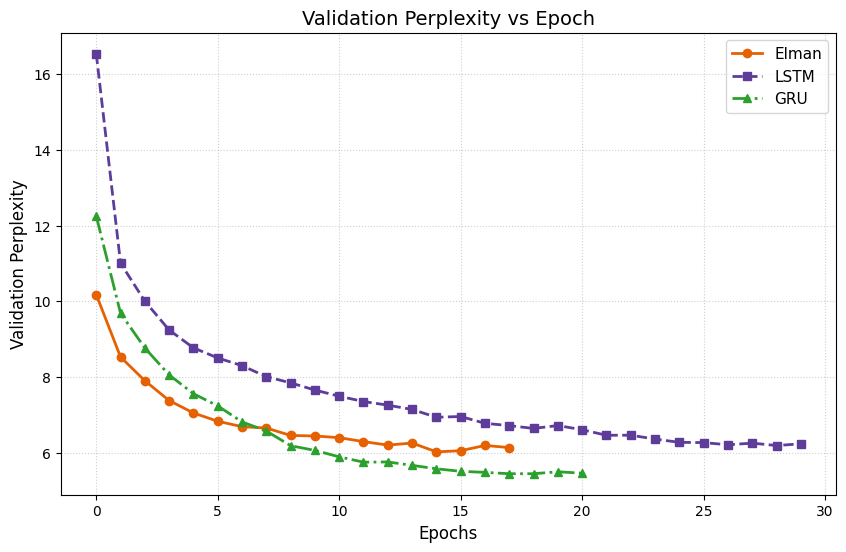

In [ ]:
# Perplexity graph
elman_logs = pd.read_csv(os.path.join(dir_path, "elman.csv"))
lstm_logs = pd.read_csv(os.path.join(dir_path, "lstm.csv"))
gru_logs = pd.read_csv(os.path.join(dir_path, "gru.csv"))

plt.figure(figsize=(10, 6), dpi=100)

plt.plot(elman_logs['val_perplexity'], marker='o', linestyle='-', color='#E66101', linewidth=2, label='Elman')
plt.plot(lstm_logs['val_perplexity'], marker='s', linestyle='--', color='#5E3C99', linewidth=2, label='LSTM')
plt.plot(gru_logs['val_perplexity'], marker='^', linestyle='-.', color='#2CA02C', linewidth=2, label='GRU')

plt.title('Validation Perplexity vs Epoch', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Perplexity', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')

plt.show()

Since the GRU model performed the best, it's the architecture we'll use moving forward.

One slight issue is that we left them to train in a previous session and we didn't save the character to index mapping we used for the training. Thus, since the mapping can change each time we run the code, we're forced to do a retrain of the selected model.

### Retrain

In [ ]:
# First, save the vocabulary mapping.
with open(os.path.join(dir_path, "vocmap.json"), 'w') as f:
    json.dump(c2i, f)

In [ ]:
# Retrain.
path_gru = os.path.join(dir_path, f"gruf.keras")

hist_gru = gru.fit(
    train_dataset,
    epochs=30,
    callbacks=[PerplexityCallback(valid_dataset, save_path=path_gru)],
)

history_df = pd.DataFrame(hist_gru.history)
history_df.to_csv(os.path.join(dir_path, "gruf.csv"), index=False)

Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 3.3615
Training Perplexity: 19.9423
Validation Perplexity: 12.0494
84/84 ━━━━━━━━━━━━━━━━━━━━ 238s 3s/step - loss: 2.9928 - perplexity: 19.9423 - val_perplexity: 12.0494
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 2.4275
Training Perplexity: 10.4776
Validation Perplexity: 9.5356
84/84 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - loss: 2.3492 - perplexity: 10.4776 - val_perplexity: 9.5356
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 2.1993
Training Perplexity: 8.6625
Validation Perplexity: 8.5823
84/84 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - loss: 2.1590 - perplexity: 8.6625 - val_perplexity: 8.5823
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 2.0733
Training Perplexity: 7.7234
Validation Perplexity: 8.1083
84/84 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - loss: 2.0442 - perplexity: 7.7234 - val_perplexity: 8.1083
Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 1.9745
Training Perplexity: 7.0220
Validation

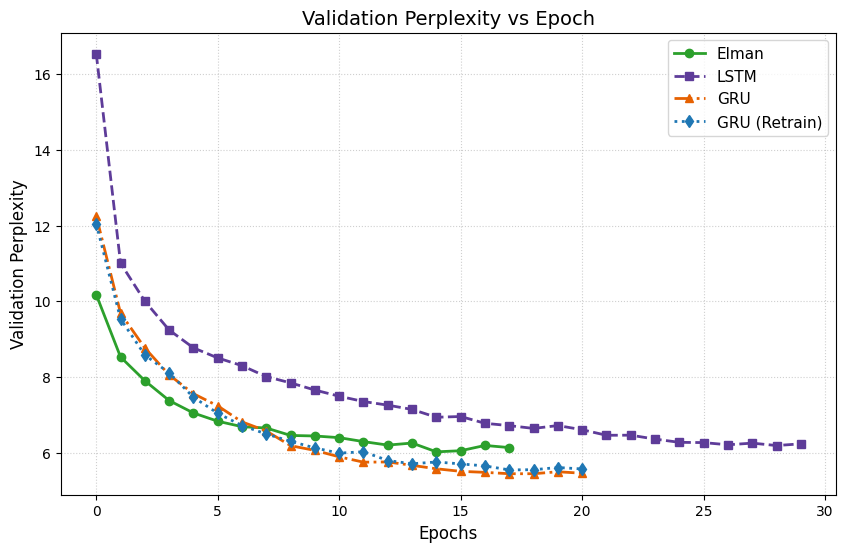

In [ ]:
# Compare with previous models.
elman_logs = pd.read_csv(os.path.join(dir_path, "elman.csv"))
lstm_logs = pd.read_csv(os.path.join(dir_path, "lstm.csv"))
gru_logs = pd.read_csv(os.path.join(dir_path, "gru.csv"))
gruf_logs = pd.read_csv(os.path.join(dir_path, "gruf.csv"))

plt.figure(figsize=(10, 6), dpi=100)

plt.plot(elman_logs['val_perplexity'], marker='o', linestyle='-', color='#2CA02C', linewidth=2, label='Elman')
plt.plot(lstm_logs['val_perplexity'], marker='s', linestyle='--', color='#5E3C99', linewidth=2, label='LSTM')
plt.plot(gru_logs['val_perplexity'], marker='^', linestyle='-.', color='#E66101', linewidth=2, label='GRU')
plt.plot(gruf_logs['val_perplexity'], marker='d', linestyle=':', color='#1F77B4', linewidth=2, label='GRU (Retrain)')

plt.title('Validation Perplexity vs Epoch', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Perplexity', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')

plt.show()


# New sequences generation

In [9]:
# Load model and chara-index dictionary.
model = tf.keras.models.load_model(os.path.join(dir_path, f"gruf.keras"))

with open(os.path.join(dir_path, "vocmap.json"), 'r') as f:
    c2i = json.load(f)
i2c = {idx: character for character, idx in c2i.items()}

max_context_size = 512

In [8]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 512, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 512, 128)       │        56,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 512, 61)        │         7,869 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,820 (507.11 KB)

 Trainable params: 64,909 (253.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64,911 (253.56 KB)

In [6]:
# Check gradio to test model
%%capture
!pip install -q gradio

In [10]:
import gradio as gr

def model_response(text):
    # Encode
    encoded = [c2i[ch] for ch in text.lower()]
    # Pad, if needed.
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')
    # Predict (no softmax needed since max(logits)=max(softmax(logits)))
    y_hat = int(np.argmax(model.predict(encoded)[0,-1,:]))
    # Prediction to character.
    output = i2c[y_hat]
    # Add to text input
    return text + output

iface = gr.Interface(
    fn=model_response,
    inputs=["textbox"],
    outputs="text")

iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ea2fc320d65d11b3a4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://ea2fc320d65d11b3a4.gradio.live


We checked a simple sentence:

Starting with "la abeja vuela por el", model produced "la abeja vuela por el ". By feeding the outputs again a few times, the model produced "la abeja vuela por el agua". Which doesn't make much sense, since bees can't fly on water, but it's not bad.

### Greedy search

In [16]:
# Function to perform greedy search generation.
def greedy_search(model, text, context_size, n_chars):
    # Since we want to "add" to the input, store it.
    output = text

    # Predict and add `n_chars` times.
    for _ in range(n_chars):
        # Encode
        encoded = [c2i[ch] for ch in output.lower()]
        # Pad, if needed.
        encoded = pad_sequences([encoded], maxlen=context_size, padding='pre')
        # Predict (no softmax needed since max(logits)=max(softmax(logits)))
        y_hat = int(np.argmax(model.predict(encoded, verbose=0)[0,-1,:]))
        # Prediction to character.
        pred_char = i2c[y_hat]
        # Add to text input
        output += pred_char

    return output

In [18]:
# Try sequences:
greedy_search(model, "la abeja vuela por el", max_context_size, n_chars=50)

'la abeja vuela por el agua, y los yacarés se había más de dienen el coa'

That's not bad for such a simple model. Towards the end it makes a few mistakes in grammar but I wouldn't say it's particularly awful for the architecture chosen.

In [19]:
# Let's try a few more. We'll pick a few that are in the original book.
greedy_search(model, "la culebra comprendió entonces que", max_context_size, n_chars=50)

'la culebra comprendió entonces que estaba comió a la cola de la cola de la cola de l'

This one is interesting.

First, the original line goes: "La culebra comprendió entonces que si su prueba del trompito era muy buena, la prueba de la abeja era simplemente extraordinaria."

Second, it seems the model went into a prediction loop, since "la cola de" just repeats afterwards. This is probably due to the deterministic and simple way the generation is done. Since it's deterministic, loops like this one are bound to exist.

Let's show it goes on for 100 and move on to a different sequence.

In [20]:
greedy_search(model, "la culebra comprendió entonces que", max_context_size, n_chars=100)

'la culebra comprendió entonces que estaba comió a la cola de la cola de la cola de la cola de la cola de la cola de la cola de la cola'

In [24]:
# Try another sequence that appears in the book.
greedy_search(model, "mientras el coatí", max_context_size, n_chars=50)

'mientras el coatís se lo que estaba comió a la cola de la cola de l'

This one gives more insight into what might be happening.

It seems at some point the generation produces the word "que", which ends up producing the word "estaba" followed by "comió", which ends up producing "a la cola" and thus the loop is triggered.

In [25]:
# Let's try one more sequence before moving to beam search.
# This one not in the book.
greedy_search(model, "en el monte los", max_context_size, n_chars=50)

'en el monte los ojos a después de la cola de la cola de la cola d'

This one also gets caught in a loop. Also doesn't make much sense.

Before moving to beam search, let's return to the first sequence, which didn't get caught in the loop, and test it for 150 characters, to see that it does eventually.

In [26]:
greedy_search(model, "la abeja vuela por el", max_context_size, n_chars=150)

'la abeja vuela por el agua, y los yacarés se había más de dienen el coaticito de la cola de la cola de la cola de la cola de la cola de la cola de la cola de la cola de la'

###  Beam search

In [34]:
from scipy.special import softmax as sc_softmax

# Class due to multiple funcitons.
class BeamSearch:
    def __init__(self, c2i={}, context_size=512, softmax=sc_softmax):
        """
        Beam search.

        Attributes:
            c2i (arg, dict): Character to index.
            i2c (dict): Index to character mapping.
            context_size (arg, int): Sequence length for the model.
        """
        self.c2i = c2i
        self.i2c = {idx: character for character, idx in c2i.items()}
        self.context_size = context_size
        self.softmax = sc_softmax

    def encode(self, text):
        """Encode text characters into padded integer sequences."""
        encoded = [self.c2i[ch] for ch in text.lower() if ch in self.c2i]
        encoded = pad_sequences([encoded], maxlen=self.context_size, padding='pre')
        return encoded

    def decode(self, seq):
        """Decode an integer sequence back into text string."""
        return ''.join([self.i2c[ch] for ch in seq])

    def select_candidates(
        self, pred, num_beams, vocab_size, history_probs, history_tokens, temp, mode
    ):
        """Evaluate top cumulative path possibilities across all beams."""
        pred_large = []

        for idx, pp in enumerate(pred):
            pred_large.extend(np.log(pp + 1e-10) + history_probs[idx])

        pred_large = np.array(pred_large)

        # Criterion
        if mode == 'det':
            # Deterministic
            idx_select = np.argsort(pred_large)[::-1][:num_beams]
        elif mode == 'sto':
            # Stochastic + random sampling
            probabilities = self.softmax(pred_large / temp)
            idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=probabilities)
        else:
            raise ValueError(f"Wrong selection mode. '{mode}' was given. 'det' and 'sto' are supported.")

        # To token index in vocab.
        new_history_tokens = np.concatenate((
            np.array(history_tokens)[idx_select // vocab_size],
            np.array([idx_select % vocab_size]).T
        ), axis=1)

        # Return log probabilities and corresponding token sequence
        return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)



    def search(self, model, text_input, num_beams, num_chars, temp=1.0, mode='det'):
        """Execute beam search (deterministic or stochastic)"""

        ### First iteration
        # Encode
        encoded = self.encode(text_input)

        # First prediction (remember model outputs logits)
        y_hat = self.softmax(model.predict(encoded, verbose=0)[0, -1, :])

        # Vocabulary size
        vocab_size = y_hat.shape[0]

        ### Search
        # Initialize tracking histories
        history_probs = [0] * num_beams
        history_tokens = [encoded[0]] * num_beams

        # Select first batch of candidates
        history_probs, history_tokens = self.select_candidates(
            [y_hat], num_beams, vocab_size, history_probs, history_tokens, temp, mode
        )

        # Main Beam search sequence loop
        for i in range(num_chars - 1):
            preds = []

            for hist in history_tokens:
                # Update sequence
                input_update = np.array([hist[i + 1:]]).copy()

                # Predict
                y_hat = self.softmax(
                    model.predict(input_update, verbose=0)[0, -1, :]
                )
                preds.append(y_hat)

            # Evaluate options
            history_probs, history_tokens = self.select_candidates(
                preds, num_beams, vocab_size, history_probs, history_tokens, temp, mode
            )

        ### Outputs
        # Extract only the generated spans from token tracking
        final_sequences = history_tokens[:, -(len(text_input) + num_chars):]

        # Decode all beams to actual text strings
        decoded_beams = [self.decode(beam) for beam in final_sequences]
        return decoded_beams

In [35]:
bs = BeamSearch(c2i)

#### Deterministic

In [36]:
# Let's try the sequences from before.
bs.search(model, "la abeja vuela por el", num_beams=10, num_chars=50, mode='det')

['la abeja vuela por el viejo yacaré que estaba que estaba también en el ',
 'la abeja vuela por el viejo yacaré que estaba que estaba también con la',
 'la abeja vuela por el viejo yacaré que estaba que estaba también de la ',
 'la abeja vuela por el viejo yacaré que estaba que estaba también con el',
 'la abeja vuela por el viejo yacaré que estaba también en el agua, y se ',
 'la abeja vuela por el viejo yacaré que estaba también con el agua, y se',
 'la abeja vuela por el viejo yacaré que estaba que estaba también a la c',
 'la abeja vuela por el viejo yacaré que estaba también en el agua, y los',
 'la abeja vuela por el viejo yacaré que estaba también con el agua, y lo',
 'la abeja vuela por el viejo yacaré que estaba que estaba también con lo']

In [37]:
bs.search(model, "la culebra comprendió entonces que", num_beams=10, num_chars=100, mode='det')

['la culebra comprendió entonces que estaba también con el agua, y los yacarés que estaba también en el agua, y los yacarés, y los yacar',
 'la culebra comprendió entonces que estaba también con el agua, y los yacarés que estaba también en el agua, y los yacarés que estaban ',
 'la culebra comprendió entonces que estaba también con el agua, y los yacarés que estaba también en el agua, y los yacarés que estaba c',
 'la culebra comprendió entonces que estaba también con el agua, y los yacarés que estaba también en el agua, y los yacarés que estaba t',
 'la culebra comprendió entonces que estaba también con el agua, y los yacarés que estaba también con el agua, y los yacarés, y los yaca',
 'la culebra comprendió entonces que estaba también con el agua, y los yacarés que estaba también en el agua, y los yacarés que estaba m',
 'la culebra comprendió entonces que estaba también con el agua, y los yacarés que estaba también en el agua, y los yacarés que estaba q',
 'la culebra comprendió ent

In [38]:
bs.search(model, "mientras el coatí", num_beams=10, num_chars=50, mode='det')

['mientras el coatís, y los yacarés, porque los yacarés, y los yacaré',
 'mientras el coatís, y los yacarés, porque estaba también en el agua',
 'mientras el coatís, y los yacarés, porque estaba también con el agu',
 'mientras el coatís, y los yacarés, porque estaba también con la col',
 'mientras el coatís, y los yacarés, porque los yacarés de la cola de',
 'mientras el coatís, y los yacarés, porque estaba también de la cola',
 'mientras el coatís, y los yacarés, porque estaba también con los di',
 'mientras el coatís, y los yacarés, porque estaba también con los oj',
 'mientras el coatís, y los yacarés, porque estaba también con el caz',
 'mientras el coatís, y los yacarés, porque estaba también con la cab']

In [39]:
bs.search(model, "en el monte los", num_beams=10, num_chars=50, mode='det')

['en el monte los yacarés, porque los yacarés, y los yacarés, porqu',
 'en el monte los yacarés, porque los yacarés, y los yacarés, y se ',
 'en el monte los yacarés, porque los yacarés, y los yacarés que es',
 'en el monte los yacarés, porque los yacarés, y los yacarés de la ',
 'en el monte los yacarés, porque los yacarés, y los yacarés, y los',
 'en el monte los yacarés, porque los yacarés, y los yacarés, y la ',
 'en el monte los yacarés, porque los yacarés, y los yacarés que se',
 'en el monte los yacarés, porque los yacarés, y los yacarés que no',
 'en el monte los yacarés, porque los yacarés, y los yacarés que el',
 'en el monte los yacarés, porque los yacarés, y los yacarés que te']

It seems the character looping observed before has gone away, but now we see a slight different looping. The model always predicts a sequence that has the words "yacarés", "agua" "también" and "estaba".

It seems sequences with these words have the highest probabilities, and with the method we're using, beams with the highest probabilities are likely to share the same history. This explains why all the outputs are so similar.

As to why these words have highest probabilities, it could be because the words "yacaré" and "yacarés" appear very often in the original book (78 times), "agua" appears 70 times and "estaba" 86 times. Also, "La guerra de los yacarés" appears to be the longest tale in the book. This implies the dataset is imbalanced, which makes sense since we've done a simple slicing for train/valid and this tale is likely to have fallen entirely on the training dataset.

#### Stochastic

In [40]:
bs.search(model, "la abeja vuela por el", num_beams=10, num_chars=50, mode='sto')

['la abeja vuela por el agua, y los yacarés de guerra, y los hombres deli',
 'la abeja vuela por el agua, y los yacarés de guerra, y los hombres de a',
 'la abeja vuela por el agua, y los yacarés de guerra, y los hombres del ',
 'la abeja vuela por el agua, y los yacarés de guerra, y los hombres de l',
 'la abeja vuela por el agua, y los yacarés de guerra, y los hombres de n',
 'la abeja vuela por el agua, y los yacarés de guerra, y los hombres del ',
 'la abeja vuela por el agua, y los yacarés de guerra, y los hombres derd',
 'la abeja vuela por el agua, y los yacarés de guerra, y los hombres de f',
 'la abeja vuela por el agua, y los yacarés de guerra, y los hombres de c',
 'la abeja vuela por el agua, y los yacarés de guerra, y los hombres de p']

In [41]:
bs.search(model, "la culebra comprendió entonces que", num_beams=10, num_chars=100, mode='sto')

['la culebra comprendió entonces que estaba también el cazador del torpedo el agua, y los pedritos después de los yacarés de la cabeza p',
 'la culebra comprendió entonces que estaba también el cazador del torpedo el agua, y los pedritos después de los yacarés de la cabeza. ',
 'la culebra comprendió entonces que estaba también el cazador del torpedo el agua, y los pedritos después de los yacarés de la cabeza p',
 'la culebra comprendió entonces que estaba también el cazador del torpedo el agua, y los pedritos después de los yacarés de la cabeza, ',
 'la culebra comprendió entonces que estaba también el cazador del torpedo el agua, y los pedritos después de los yacarés de la cabeza p',
 'la culebra comprendió entonces que estaba también el cazador del torpedo el agua, y los pedritos después de los yacarés de la cabeza n',
 'la culebra comprendió entonces que estaba también el cazador del torpedo el agua, y los pedritos después de los yacarés de la cabeza d',
 'la culebra comprendió ent

In [42]:
bs.search(model, "mientras el coatí", num_beams=10, num_chars=50, mode='sto')

['mientras el coatís se acercó el hombre que estaba como una vez de s',
 'mientras el coatís se acercó el hombre que estaba como una vez el r',
 'mientras el coatís se acercó el hombre que estaba como una vez de f',
 'mientras el coatís se acercó el hombre que estaba como una vez el a',
 'mientras el coatís se acercó el hombre que estaba como una vez coni',
 'mientras el coatís se acercó el hombre que estaba como una vez el b',
 'mientras el coatís se acercó el hombre que estaba como una vez come',
 'mientras el coatís se acercó el hombre que estaba como una vez de m',
 'mientras el coatís se acercó el hombre que estaba como una vez el o',
 'mientras el coatís se acercó el hombre que estaba como una vez de s']

In [43]:
bs.search(model, "en el monte los", num_beams=10, num_chars=50, mode='sto')

['en el monte los ojos arritado con el monte, que estaba también pl',
 'en el monte los ojos arritado con el monte, que estaba también ll',
 'en el monte los ojos arritado con el monte, que estaba también a ',
 'en el monte los ojos arritado con el monte, que estaba también el',
 'en el monte los ojos arritado con el monte, que estaba también y ',
 'en el monte los ojos arritado con el monte, que estaba también de',
 'en el monte los ojos arritado con el monte, que estaba también ad',
 'en el monte los ojos arritado con el monte, que estaba también en',
 'en el monte los ojos arritado con el monte, que estaba también de',
 'en el monte los ojos arritado con el monte, que estaba también a ']

By switching to stochastic search (temperature = 1, as default) we see different results.

First thing that stood out is that repetition of words or structures seems to be completely gone, except maybe for the last one: "en el monte los ojos arritado con el monte...". At least we know the search is working, since it doesn't loop on itself after the second "el monte".

This seems to have allowed the model to use words and concepts from the other stories, while using more concepts from the yacaré story. While this improved, the sentences don't seem to have as much of a strong logic in structure anymore. Also we still see that all the outputs are basically identical.

#### Temperature

We took the second sequence and tweaked the temperature.

In [44]:
bs.search(model, "la culebra comprendió entonces que", num_beams=10, num_chars=100, temp=0.2, mode='sto')

['la culebra comprendió entonces que estaba comió de la cola del torpedo de la cola del torpedo de la cola del torpedo de la cola del to',
 'la culebra comprendió entonces que estaba comió de la cola del torpedo de la cola del torpedo de la cola del torpedo de la cola del to',
 'la culebra comprendió entonces que estaba comió de la cola del torpedo de la cola del torpedo de la cola del torpedo de la cola del to',
 'la culebra comprendió entonces que estaba comió de la cola del torpedo de la cola del torpedo de la cola del torpedo de la cola del to',
 'la culebra comprendió entonces que estaba comió de la cola del torpedo de la cola del torpedo de la cola del torpedo de la cola del to',
 'la culebra comprendió entonces que estaba comió de la cola del torpedo de la cola del torpedo de la cola del torpedo de la cola del to',
 'la culebra comprendió entonces que estaba comió de la cola del torpedo de la cola del torpedo de la cola del torpedo de la cola del to',
 'la culebra comprendió ent

In [45]:
bs.search(model, "la culebra comprendió entonces que", num_beams=10, num_chars=100, temp=0.7, mode='sto')

['la culebra comprendió entonces que estaba como una gran alegría de la cabeza de la colmena, y la cabeza de la cola del torpedo que los',
 'la culebra comprendió entonces que estaba como una gran alegría de la cabeza de la colmena, y la cabeza de la cola del torpedo que est',
 'la culebra comprendió entonces que estaba como una gran alegría de la cabeza de la colmena, y la cabeza de la cola del torpedo que est',
 'la culebra comprendió entonces que estaba como una gran alegría de la cabeza de la colmena, y la cabeza de la cola del torpedo que lo ',
 'la culebra comprendió entonces que estaba como una gran alegría de la cabeza de la colmena, y la cabeza de la cola del torpedo que sab',
 'la culebra comprendió entonces que estaba como una gran alegría de la cabeza de la colmena, y la cabeza de la cola del torpedo que hab',
 'la culebra comprendió entonces que estaba como una gran alegría de la cabeza de la colmena, y la cabeza de la cola del torpedo que la ',
 'la culebra comprendió ent

In [46]:
bs.search(model, "la culebra comprendió entonces que", num_beams=10, num_chars=100, temp=1.5, mode='sto')

['la culebra comprendió entonces que la colmena, y le había más fuerza. con el cazador, y la tortuga, y le dijo entonces a los hombres e',
 'la culebra comprendió entonces que la colmena, y le había más fuerza. con el cazador, y la tortuga, y le dijo entonces a los hombres r',
 'la culebra comprendió entonces que la colmena, y le había más fuerza. con el cazador, y la tortuga, y le dijo entonces a los hombres q',
 'la culebra comprendió entonces que la colmena, y le había más fuerza. con el cazador, y la tortuga, y le dijo entonces a los hombres y',
 'la culebra comprendió entonces que la colmena, y le había más fuerza. con el cazador, y la tortuga, y le dijo entonces a los hombres r',
 'la culebra comprendió entonces que la colmena, y le había más fuerza. con el cazador, y la tortuga, y le dijo entonces a los hombres e',
 'la culebra comprendió entonces que la colmena, y le había más fuerza. con el cazador, y la tortuga, y le dijo entonces a los hombres d',
 'la culebra comprendió ent

We see that for temp=0.2, we seem to get back the greedy search behaviour. The sequence "de la cola del torpedo" just repeats over and over.

For temp=0.7, we see a bit of logic in the output. It seems to have hit the high probability sequence "de la cola del torpedo", but looking at the last few characters it doesn't seem that it would get stuck on it, had we kept going. Of the 4 temperatures tried (counting temp=1 from above), this seem to be the best value for it, since the model seems to pull from different tales but also has decent grammar.

For temp=1.5, we see while a quick look might make it seem like it's okay, the output has lost coherence. It introduced people and animals instead of developing what was written before.

Finally, we still see that all beams share the same history. This means that temperature might change what the model predicts from the input sequence, but it doesn't increase the diversity in the beams. The beams are all still sharing the same root and only branch out at the end.